<a href="https://colab.research.google.com/github/Fatima-Shahid11/Fashion_Image_Classifier/blob/main/Fashion_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Check if GPU is available and use it if so
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch version:", torch.__version__)
print("Device we'll train on:", device)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

PyTorch version: 2.11.0+cpu
Device we'll train on: cpu
GPU name: no GPU


In [ ]:
# Define the preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                    # PIL image → tensor, scale 0-255 to 0-1
    transforms.Normalize((0.5,), (0.5,))      # shift to range -1 to 1
])

# Download the data (first time: downloads ~30 MB, after that: instant from cache)
train_data = datasets.FashionMNIST(
    root='./data',         # where to save it on disk
    train=True,            # the training portion
    download=True,
    transform=transform    # apply our preprocessing to each image as it's loaded
)

test_data = datasets.FashionMNIST(
    root='./data',
    train=False,           # the test portion
    download=True,
    transform=transform
)

# Human-readable class names (the dataset stores numeric labels 0-9)
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training images: {len(train_data)}")
print(f"Test images:     {len(test_data)}")

Training images: 60000
Test images:     10000


In [ ]:
# Grab the very first training image and its label
image_tensor, label = train_data[0]

print(f"Label number: {label}")
print(f"Label name:   {classes[label]}")
print(f"Tensor shape: {image_tensor.shape}")
print(f"Pixel values range from {image_tensor.min():.2f} to {image_tensor.max():.2f}")

Label number: 9
Label name:   Ankle boot
Tensor shape: torch.Size([1, 28, 28])
Pixel values range from -1.00 to 1.00


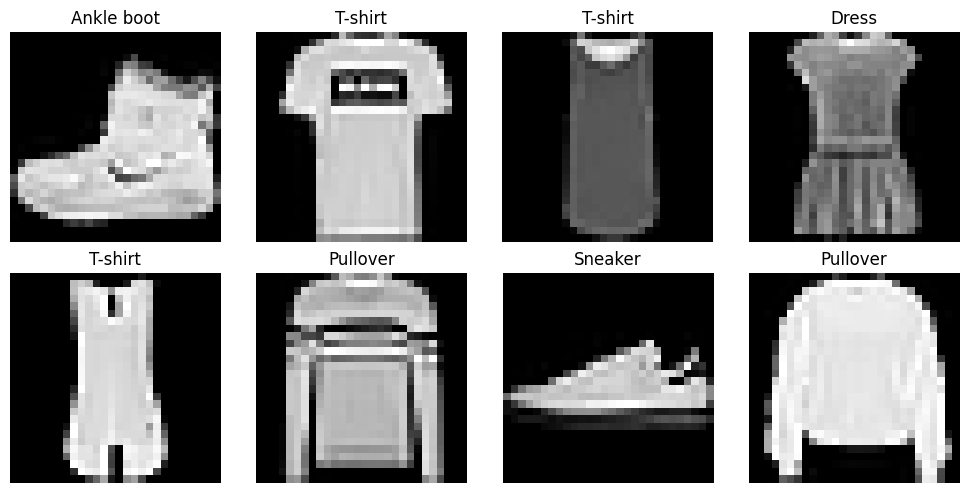

In [ ]:
# Show 8 random training images with their labels
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    # image is [1, 28, 28]; .squeeze() removes the channel dim → [28, 28] so matplotlib can plot it
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# Look at one batch to confirm it works
images, labels = next(iter(train_loader))

print(f"Batch shape:  {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"First 8 labels in this batch: {labels[:8].tolist()}")

Batch shape:  torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
First 8 labels in this batch: [1, 4, 9, 4, 5, 1, 3, 3]


In [ ]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = FashionCNN().to(device)
print(model)

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
images, labels = next(iter(train_loader))
output = model(images.to(device))
print(f"Input:  {images.shape}")
print(f"Output: {output.shape}")

Input:  torch.Size([64, 1, 28, 28])
Output: torch.Size([64, 10])


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()                # tell PyTorch we're in training mode
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Forward pass
        outputs = model(images)

        # 2. Compute loss
        loss = loss_fn(outputs, labels)

        # 3. Zero gradients
        optimizer.zero_grad()

        # 4. Backward pass
        loss.backward()

        # 5. Update weights
        optimizer.step()

        # Track stats
        total_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    print(f"Epoch {epoch+1}: loss = {avg_loss:.4f}, accuracy = {accuracy:.4f}")

Epoch 1: loss = 0.4246, accuracy = 0.8449
Epoch 2: loss = 0.2759, accuracy = 0.9000
Epoch 3: loss = 0.2305, accuracy = 0.9147
Epoch 4: loss = 0.2020, accuracy = 0.9260
Epoch 5: loss = 0.1759, accuracy = 0.9353


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9195


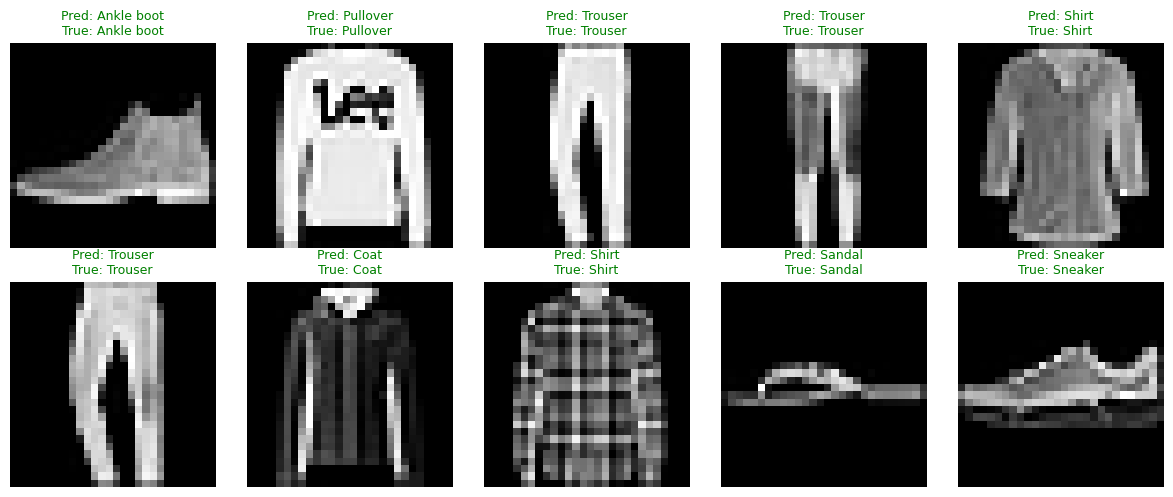

In [ ]:
images, labels = next(iter(test_loader))
images_dev = images.to(device)

with torch.no_grad():
    outputs = model(images_dev)
    predicted = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}",
                 color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

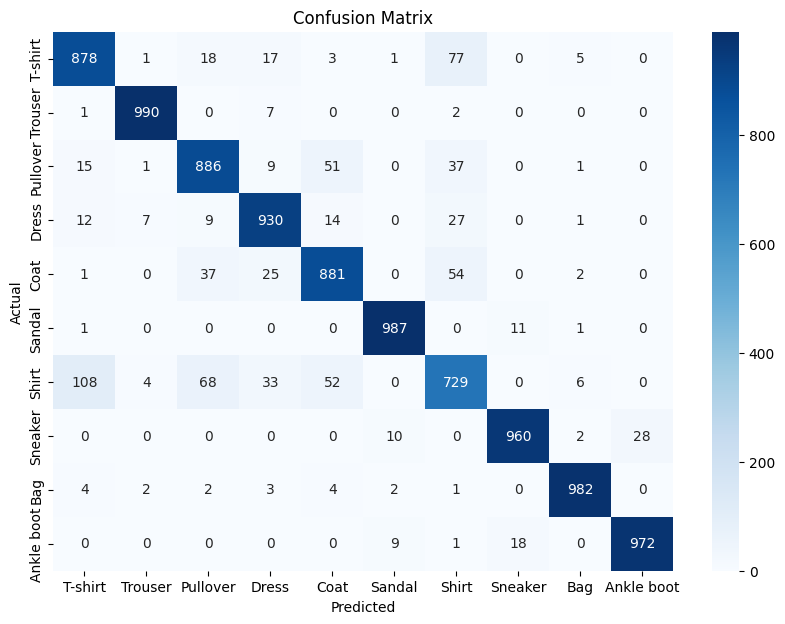

              precision    recall  f1-score   support

     T-shirt       0.86      0.88      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.89      0.88      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.88      0.88      0.88      1000
      Sandal       0.98      0.99      0.98      1000
       Shirt       0.79      0.73      0.76      1000
     Sneaker       0.97      0.96      0.97      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=classes))